# NeRF Colab Notebook (single-file version)

This notebook consolidates the current repo into one Colab-friendly workflow:
- LLFF data loading
- ray generation
- point sampling
- positional encoding
- NeRF model
- volume rendering
- trainer
- checkpointing
- validation rendering

It is designed for the current repo contents and the trainer logic we updated in chat.  
Upload your LLFF scene folder to Colab first, then set `SCENE_PATH` below.

In [3]:
# !rm -rf data/nerf_llff_data
# !rm -f data/nerf_llff_data.rar

In [4]:

# Optional: install/update packages in Colab
!pip -q install imageio matplotlib
!apt-get install unrar
!unrar x data/nerf_llff_data.rar data/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from data/nerf_llff_data.rar


Would you like to replace the existing file data/nerf_llff_data/fern/database.db
38428672 bytes, modified on 2020-03-19 22:31
with a new one
38428672 bytes, modified on 2020-03-19 22:31

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit q

Program aborted


## 1) Set paths and runtime

Before running training:
1. In Colab, go to **Runtime > Change runtime type > GPU**
2. Upload your dataset so the scene folder contains:
   - `images/`
   - `poses_bounds.npy`

Example:
`/content/data/nerf_llff_data/fern`

In [5]:

from pathlib import Path
import os

SCENE_PATH = "/content/data/nerf_llff_data/fern"
EXP_NAME = "fern_baseline_colab"

assert Path(SCENE_PATH).exists(), f"Scene path not found: {SCENE_PATH}"
print("Scene path:", SCENE_PATH)
print("Files:", sorted([p.name for p in Path(SCENE_PATH).iterdir()])[:10])

Scene path: /content/data/nerf_llff_data/fern
Files: ['database.db', 'images', 'images_4', 'images_8', 'mpis4', 'poses_bounds.npy', 'simplices.npy', 'sparse', 'trimesh.png']


## 2) Imports

In [6]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import random

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

## 3) Reproducibility helpers

In [7]:

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 4) LLFF data loader + optional depth maps

In [8]:

@dataclass
class LLFFData:
    images: np.ndarray
    poses: np.ndarray
    bounds: np.ndarray
    height: int
    width: int
    focal: float
    depths: np.ndarray | None = None
    depth_valid_mask: np.ndarray | None = None

    @property
    def n_images(self) -> int:
        return self.images.shape[0]

    @property
    def has_depth(self) -> bool:
        return self.depths is not None


def _load_images(images_dir: str | Path) -> np.ndarray:
    images_dir = Path(images_dir)
    exts = {".png", ".jpg", ".jpeg", ".JPG", ".PNG", ".JPEG"}
    image_paths = sorted([p for p in images_dir.iterdir() if p.suffix in exts])
    if len(image_paths) == 0:
        raise FileNotFoundError(f"No images found in {images_dir}")

    images = []
    for p in image_paths:
        img = Image.open(p).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        images.append(img)

    return np.stack(images, axis=0)


def _load_depth_stack_from_dir(depth_dir: Path, expected_hw: tuple[int, int]) -> np.ndarray:
    depth_files = sorted(
        [p for p in depth_dir.iterdir() if p.suffix.lower() in {".npy", ".png", ".jpg", ".jpeg"}]
    )
    if len(depth_files) == 0:
        raise FileNotFoundError(f"No depth files found in {depth_dir}")

    depths = []
    exp_h, exp_w = expected_hw
    for p in depth_files:
        if p.suffix.lower() == ".npy":
            depth = np.load(p).astype(np.float32)
        else:
            # Works for 16-bit PNG depth exports too.
            depth = np.array(Image.open(p)).astype(np.float32)
        if depth.ndim == 3:
            depth = depth[..., 0]
        if depth.shape != (exp_h, exp_w):
            raise ValueError(
                f"Depth shape mismatch for {p.name}: expected {(exp_h, exp_w)}, got {depth.shape}"
            )
        depths.append(depth)

    return np.stack(depths, axis=0)


def _load_optional_depths(scene_path: Path, n_images: int, expected_hw: tuple[int, int]):
    candidate_npy = [
        scene_path / "depths.npy",
        scene_path / "depth_maps.npy",
        scene_path / "depth" / "depths.npy",
    ]
    candidate_dirs = [
        scene_path / "depths",
        scene_path / "depth",
        scene_path / "depth_maps",
    ]

    depths = None
    for p in candidate_npy:
        if p.exists():
            depths = np.load(p).astype(np.float32)
            break

    if depths is None:
        for d in candidate_dirs:
            if d.exists() and d.is_dir():
                depths = _load_depth_stack_from_dir(d, expected_hw)
                break

    if depths is None:
        print("[info] No depth maps found. Depth loss will be disabled.")
        return None, None

    if depths.ndim == 4 and depths.shape[-1] == 1:
        depths = depths[..., 0]
    if depths.ndim != 3:
        raise ValueError(f"Expected depth tensor of shape [N, H, W], got {depths.shape}")
    if depths.shape[0] != n_images:
        raise ValueError(
            f"Depth/image count mismatch: {depths.shape[0]} depth maps vs {n_images} RGB images"
        )
    if depths.shape[1:] != expected_hw:
        raise ValueError(
            f"Depth/image resolution mismatch: {depths.shape[1:]} vs {expected_hw}"
        )

    valid_mask = np.isfinite(depths) & (depths > 0.0)
    depths = np.nan_to_num(depths, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    print(
        f"[info] Loaded depth maps for supervision: shape={depths.shape}, "
        f"valid_ratio={valid_mask.mean():.4f}"
    )
    return depths, valid_mask.astype(np.float32)


def load_llff_data(scene_path: str | Path, load_depths: bool = True) -> LLFFData:
    scene_path = Path(scene_path)
    images_dir = scene_path / "images"
    poses_bounds_path = scene_path / "poses_bounds.npy"

    if not images_dir.exists():
        raise FileNotFoundError(f"Missing images directory: {images_dir}")
    if not poses_bounds_path.exists():
        raise FileNotFoundError(f"Missing poses_bounds.npy: {poses_bounds_path}")

    images = _load_images(images_dir)
    poses_bounds = np.load(poses_bounds_path)

    poses = poses_bounds[:, :-2].reshape(-1, 3, 5).astype(np.float32)
    bounds = poses_bounds[:, -2:].astype(np.float32)

    hwf = poses[:, :, 4]
    poses = poses[:, :, :4]

    h = int(hwf[0, 0])
    w = int(hwf[0, 1])
    focal = float(hwf[0, 2])

    actual_h, actual_w = images.shape[1], images.shape[2]
    if (actual_h != h) or (actual_w != w):
        print(f"[warning] H/W in poses_bounds.npy = ({h}, {w}), but actual images = ({actual_h}, {actual_w}). Using actual image size.")
        h, w = actual_h, actual_w

    depths, depth_valid_mask = (None, None)
    if load_depths:
        depths, depth_valid_mask = _load_optional_depths(
            scene_path=scene_path,
            n_images=images.shape[0],
            expected_hw=(h, w),
        )

    return LLFFData(
        images=images,
        poses=poses,
        bounds=bounds,
        height=h,
        width=w,
        focal=focal,
        depths=depths,
        depth_valid_mask=depth_valid_mask,
    )


def train_val_test_split(n_images: int, hold_every: int = 8):
    all_idx = np.arange(n_images)
    test_idx = all_idx[::hold_every]
    val_idx = test_idx.copy()
    train_idx = np.array([i for i in all_idx if i not in set(test_idx)], dtype=np.int64)
    return train_idx, val_idx, test_idx


## 5) Ray generation

In [9]:

def get_rays(height: int, width: int, focal: float, c2w: np.ndarray):
    i, j = np.meshgrid(
        np.arange(width, dtype=np.float32),
        np.arange(height, dtype=np.float32),
        indexing="xy"
    )

    dirs = np.stack([
        (i - width * 0.5) / focal,
        -(j - height * 0.5) / focal,
        -np.ones_like(i)
    ], axis=-1)

    rot = c2w[:, :3]
    trans = c2w[:, 3]

    rays_d = dirs @ rot.T
    rays_o = np.broadcast_to(trans, rays_d.shape).copy()

    return rays_o.astype(np.float32), rays_d.astype(np.float32)


def get_rays_flat(height: int, width: int, focal: float, c2w: np.ndarray):
    rays_o, rays_d = get_rays(height, width, focal, c2w)
    return rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)

## 6) Point sampling along rays

In [10]:

def sample_points(
    rays_o: np.ndarray,
    rays_d: np.ndarray,
    near: float,
    far: float,
    n_samples: int,
    perturb: bool = False,
):
    n_rays = rays_o.shape[0]

    z_vals = np.linspace(near, far, n_samples, dtype=np.float32)
    z_vals = np.broadcast_to(z_vals[None, :], (n_rays, n_samples)).copy()

    if perturb:
        mids = 0.5 * (z_vals[:, :-1] + z_vals[:, 1:])
        upper = np.concatenate([mids, z_vals[:, -1:]], axis=-1)
        lower = np.concatenate([z_vals[:, :1], mids], axis=-1)
        t_rand = np.random.rand(*z_vals.shape).astype(np.float32)
        z_vals = lower + (upper - lower) * t_rand

    points = rays_o[:, None, :] + rays_d[:, None, :] * z_vals[:, :, None]
    return z_vals.astype(np.float32), points.astype(np.float32)

## 7) Positional encoding

In [11]:

class PositionalEncoder:
    def __init__(self, num_freqs: int, include_input: bool = True):
        self.num_freqs = num_freqs
        self.include_input = include_input
        self.freq_bands = 2.0 ** np.arange(num_freqs, dtype=np.float32)

    def output_dim(self, input_dim: int) -> int:
        base = input_dim if self.include_input else 0
        return base + input_dim * 2 * self.num_freqs

    def encode(self, x: np.ndarray) -> np.ndarray:
        out = []
        if self.include_input:
            out.append(x)
        for freq in self.freq_bands:
            out.append(np.sin(freq * x))
            out.append(np.cos(freq * x))
        return np.concatenate(out, axis=-1).astype(np.float32)

## 8) NeRF model

In [12]:

class NeRF(nn.Module):
    def __init__(
        self,
        input_ch: int,
        input_ch_dir: int,
        depth: int = 8,
        width: int = 256,
        skips: tuple[int, ...] = (4,),
    ):
        super().__init__()
        self.input_ch = input_ch
        self.input_ch_dir = input_ch_dir
        self.depth = depth
        self.width = width
        self.skips = set(skips)

        pts_layers = []
        for i in range(depth):
            if i == 0:
                in_ch = input_ch
            elif i in self.skips:
                in_ch = width + input_ch
            else:
                in_ch = width
            pts_layers.append(nn.Linear(in_ch, width))
        self.pts_linears = nn.ModuleList(pts_layers)

        self.sigma_linear = nn.Linear(width, 1)
        self.feature_linear = nn.Linear(width, width)

        self.view_linear = nn.Linear(width + input_ch_dir, width // 2)
        self.rgb_linear = nn.Linear(width // 2, 3)

    def forward(self, x_pts: torch.Tensor, x_dirs: torch.Tensor):
        h = x_pts
        for i, layer in enumerate(self.pts_linears):
            if i in self.skips:
                h = torch.cat([h, x_pts], dim=-1)
            h = F.relu(layer(h))

        sigma = F.relu(self.sigma_linear(h))
        features = self.feature_linear(h)

        h_dir = torch.cat([features, x_dirs], dim=-1)
        h_dir = F.relu(self.view_linear(h_dir))
        rgb = torch.sigmoid(self.rgb_linear(h_dir))
        return rgb, sigma

## 9) Volume rendering

In [13]:

def volume_render(rgb, sigma, z_vals, rays_d, white_bkgd: bool = False):
    sigma = sigma.squeeze(-1)

    dists = z_vals[:, 1:] - z_vals[:, :-1]
    infinity_pad = torch.full_like(dists[:, :1], 1e10)
    dists = torch.cat([dists, infinity_pad], dim=-1)

    ray_norms = torch.norm(rays_d, dim=-1, keepdim=True)
    dists = dists * ray_norms

    alpha = 1.0 - torch.exp(-sigma * dists)

    trans = torch.cumprod(
        torch.cat(
            [torch.ones((alpha.shape[0], 1), device=alpha.device), 1.0 - alpha + 1e-10],
            dim=-1,
        ),
        dim=-1,
    )[:, :-1]

    weights = alpha * trans
    rgb_map = torch.sum(weights[..., None] * rgb, dim=1)
    depth_map = torch.sum(weights * z_vals, dim=1)
    acc_map = torch.sum(weights, dim=1)

    if white_bkgd:
        rgb_map = rgb_map + (1.0 - acc_map[..., None])

    return rgb_map, depth_map, acc_map, weights

## 10) Quick data sanity check

Images: (20, 3024, 4032, 3)
Poses: (20, 3, 4)
Bounds: (20, 2)
H, W, focal: 3024 4032 3260.5263671875
Train / Val / Test: 17 3 3


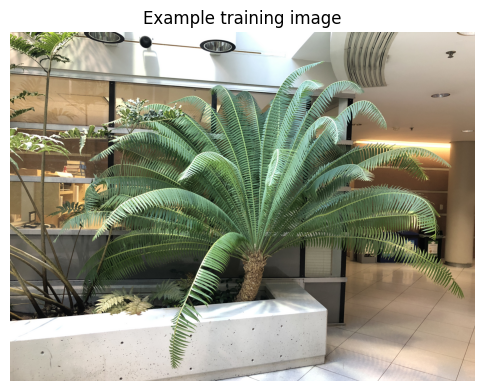

In [14]:

data = load_llff_data(SCENE_PATH)
train_idx, val_idx, test_idx = train_val_test_split(data.n_images, hold_every=8)

print("Images:", data.images.shape)
print("Poses:", data.poses.shape)
print("Bounds:", data.bounds.shape)
print("H, W, focal:", data.height, data.width, data.focal)
print("Train / Val / Test:", len(train_idx), len(val_idx), len(test_idx))

plt.figure(figsize=(6, 6))
plt.imshow(data.images[0])
plt.title("Example training image")
plt.axis("off")
plt.show()

## 11) Forward-pass sanity test

In [15]:

xyz_encoder = PositionalEncoder(num_freqs=10)
dir_encoder = PositionalEncoder(num_freqs=4)

model = NeRF(
    input_ch=xyz_encoder.output_dim(3),
    input_ch_dir=dir_encoder.output_dim(3),
).to(DEVICE)

pose0 = data.poses[0]
rays_o_np, rays_d_np = get_rays_flat(data.height, data.width, data.focal, pose0)

subset = 128
rays_o_np = rays_o_np[:subset]
rays_d_np = rays_d_np[:subset]

near = float(data.bounds.min())
far = float(data.bounds.max())

z_vals_np, points_np = sample_points(
    rays_o_np, rays_d_np, near=near, far=far, n_samples=64, perturb=False
)

encoded_points_np = xyz_encoder.encode(points_np)
encoded_dirs_np = dir_encoder.encode(rays_d_np)
encoded_dirs_np = np.repeat(encoded_dirs_np[:, None, :], 64, axis=1)

encoded_points = torch.from_numpy(encoded_points_np).float().to(DEVICE)
encoded_dirs = torch.from_numpy(encoded_dirs_np).float().to(DEVICE)
z_vals = torch.from_numpy(z_vals_np).float().to(DEVICE)
rays_d = torch.from_numpy(rays_d_np).float().to(DEVICE)

n_rays, n_samples, feat_dim = encoded_points.shape
dir_dim = encoded_dirs.shape[-1]

rgb_flat, sigma_flat = model(
    encoded_points.reshape(-1, feat_dim),
    encoded_dirs.reshape(-1, dir_dim)
)

rgb = rgb_flat.reshape(n_rays, n_samples, 3)
sigma = sigma_flat.reshape(n_rays, n_samples, 1)

rgb_map, depth_map, acc_map, weights = volume_render(rgb, sigma, z_vals, rays_d)

print("rgb_map:", tuple(rgb_map.shape))
print("depth_map:", tuple(depth_map.shape))
print("acc_map:", tuple(acc_map.shape))
print("weights:", tuple(weights.shape))

rgb_map: (128, 3)
depth_map: (128,)
acc_map: (128,)
weights: (128, 64)


## 12) Trainer with optional depth loss

In [16]:

@dataclass
class TrainConfig:
    scene_path: str = SCENE_PATH
    exp_name: str = EXP_NAME

    num_epochs: int = 10
    steps_per_epoch: int = 500

    batch_size: int = 512
    n_samples: int = 64

    lr: float = 5e-4
    lr_decay_step: int = 250
    lr_decay_gamma: float = 0.5

    xyz_num_freqs: int = 10
    dir_num_freqs: int = 4

    hold_every: int = 8
    white_bkgd: bool = False

    # Depth-supervision controls
    load_depths: bool = True
    depth_loss_weight: float = 1.0
    use_depth_loss: bool = True

    # Validation controls
    validate_every: int = 200
    validate_at_epoch_end: bool = True
    full_val_every_epochs: int = 1
    mini_val_num_rays: int = 4096
    fixed_val_image_idx: int | None = None
    save_val_image: bool = True

    save_every: int = 500
    log_every: int = 25

    render_chunk_size: int = 512
    device: str = DEVICE
    seed: int = 42


class NeRFTrainer:
    def __init__(self, config: TrainConfig):
        self.cfg = config
        self.device = torch.device(config.device)

        seed_everything(config.seed)

        self.scene_path = Path(config.scene_path)
        self.exp_dir = Path("/content/outputs") / config.exp_name
        self.ckpt_dir = self.exp_dir / "checkpoints"
        self.val_dir = self.exp_dir / "val_renders"
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.val_dir.mkdir(parents=True, exist_ok=True)

        self.data = load_llff_data(self.scene_path, load_depths=config.load_depths)
        self.train_idx, self.val_idx, self.test_idx = train_val_test_split(
            self.data.n_images,
            hold_every=config.hold_every,
        )

        self.height = self.data.height
        self.width = self.data.width
        self.focal = self.data.focal
        self.near = float(self.data.bounds.min())
        self.far = float(self.data.bounds.max())

        self.xyz_encoder = PositionalEncoder(num_freqs=config.xyz_num_freqs)
        self.dir_encoder = PositionalEncoder(num_freqs=config.dir_num_freqs)

        self.model = NeRF(
            input_ch=self.xyz_encoder.output_dim(3),
            input_ch_dir=self.dir_encoder.output_dim(3),
        ).to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=config.lr)
        self.scheduler = StepLR(
            self.optimizer,
            step_size=config.lr_decay_step,
            gamma=config.lr_decay_gamma,
        )

        self.global_step = 0
        self.train_loss_window = []
        self.train_psnr_window = []

        print(f"[trainer] Scene path: {self.scene_path}")
        print(f"[trainer] Train images: {len(self.train_idx)}")
        print(f"[trainer] Val images: {len(self.val_idx)}")
        print(f"[trainer] Test images: {len(self.test_idx)}")
        print(f"[trainer] Image size: {self.height} x {self.width}")
        print(f"[trainer] Near/Far: {self.near:.4f} / {self.far:.4f}")
        print(f"[trainer] Device: {self.device}")
        print(f"[trainer] Depth supervision available: {self.data.has_depth}")
        print(
            f"[trainer] Depth loss active: "
            f"{bool(self.cfg.use_depth_loss and self.data.has_depth)} "
            f"(weight={self.cfg.depth_loss_weight})"
        )

    def sample_random_batch(self):
        img_idx = int(np.random.choice(self.train_idx))
        pose = self.data.poses[img_idx]
        image = self.data.images[img_idx]

        rays_o_np, rays_d_np = get_rays_flat(self.height, self.width, self.focal, pose)
        rgb_np = image.reshape(-1, 3).astype(np.float32)

        depth_np = None
        depth_mask_np = None
        if self.data.has_depth:
            depth_np = self.data.depths[img_idx].reshape(-1).astype(np.float32)
            depth_mask_np = self.data.depth_valid_mask[img_idx].reshape(-1).astype(np.float32)

        n_pixels = rays_o_np.shape[0]
        replace = self.cfg.batch_size > n_pixels
        pixel_idx = np.random.choice(n_pixels, size=self.cfg.batch_size, replace=replace)

        rays_o = torch.from_numpy(rays_o_np[pixel_idx]).float().to(self.device)
        rays_d = torch.from_numpy(rays_d_np[pixel_idx]).float().to(self.device)
        target_rgb = torch.from_numpy(rgb_np[pixel_idx]).float().to(self.device)

        target_depth = None
        target_depth_mask = None
        if depth_np is not None:
            target_depth = torch.from_numpy(depth_np[pixel_idx]).float().to(self.device)
            target_depth_mask = torch.from_numpy(depth_mask_np[pixel_idx]).float().to(self.device)

        return rays_o, rays_d, target_rgb, target_depth, target_depth_mask

    def get_validation_image_idx(self):
        if len(self.val_idx) == 0:
            raise RuntimeError("Validation split is empty.")

        if self.cfg.fixed_val_image_idx is not None:
            return int(self.cfg.fixed_val_image_idx)

        return int(self.val_idx[0])

    def render_rays(self, rays_o: torch.Tensor, rays_d: torch.Tensor, perturb: bool = False):
        rays_o_np = rays_o.detach().cpu().numpy()
        rays_d_np = rays_d.detach().cpu().numpy()

        z_vals_np, points_np = sample_points(
            rays_o=rays_o_np,
            rays_d=rays_d_np,
            near=self.near,
            far=self.far,
            n_samples=self.cfg.n_samples,
            perturb=perturb,
        )

        encoded_points_np = self.xyz_encoder.encode(points_np)
        encoded_dirs_np = self.dir_encoder.encode(rays_d_np)
        encoded_dirs_np = np.repeat(
            encoded_dirs_np[:, None, :],
            self.cfg.n_samples,
            axis=1,
        )

        encoded_points = torch.from_numpy(encoded_points_np).float().to(self.device)
        encoded_dirs = torch.from_numpy(encoded_dirs_np).float().to(self.device)
        z_vals = torch.from_numpy(z_vals_np).float().to(self.device)

        n_rays, n_samples, feat_dim = encoded_points.shape
        dir_dim = encoded_dirs.shape[-1]

        rgb_flat, sigma_flat = self.model(
            encoded_points.reshape(-1, feat_dim),
            encoded_dirs.reshape(-1, dir_dim),
        )

        rgb = rgb_flat.reshape(n_rays, n_samples, 3)
        sigma = sigma_flat.reshape(n_rays, n_samples, 1)

        rgb_map, depth_map, acc_map, weights = volume_render(
            rgb=rgb,
            sigma=sigma,
            z_vals=z_vals,
            rays_d=rays_d,
            white_bkgd=self.cfg.white_bkgd,
        )

        return {
            "rgb_map": rgb_map,
            "depth_map": depth_map,
            "acc_map": acc_map,
            "weights": weights,
            "z_vals": z_vals,
        }

    def compute_depth_loss(
        self,
        pred_depth: torch.Tensor,
        target_depth: torch.Tensor | None,
        target_depth_mask: torch.Tensor | None,
    ):
        if target_depth is None or target_depth_mask is None:
            return None

        valid = target_depth_mask > 0.5
        if torch.count_nonzero(valid) == 0:
            return None

        return F.mse_loss(pred_depth[valid], target_depth[valid])

    def train_step(self):
        self.model.train()

        rays_o, rays_d, target_rgb, target_depth, target_depth_mask = self.sample_random_batch()
        outputs = self.render_rays(rays_o, rays_d, perturb=True)
        pred_rgb = outputs["rgb_map"]
        pred_depth = outputs["depth_map"]

        rgb_loss = F.mse_loss(pred_rgb, target_rgb)
        depth_loss = None
        if self.cfg.use_depth_loss and self.data.has_depth:
            depth_loss = self.compute_depth_loss(pred_depth, target_depth, target_depth_mask)

        loss = rgb_loss
        if depth_loss is not None:
            loss = loss + self.cfg.depth_loss_weight * depth_loss

        psnr = -10.0 * torch.log10(rgb_loss + 1e-10)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.global_step += 1

        self.train_loss_window.append(float(loss.item()))
        self.train_psnr_window.append(float(psnr.item()))
        if len(self.train_loss_window) > 100:
            self.train_loss_window.pop(0)
        if len(self.train_psnr_window) > 100:
            self.train_psnr_window.pop(0)

        return {
            "loss": float(loss.item()),
            "rgb_loss": float(rgb_loss.item()),
            "depth_loss": None if depth_loss is None else float(depth_loss.item()),
            "psnr": float(psnr.item()),
            "loss_ma": float(np.mean(self.train_loss_window)),
            "psnr_ma": float(np.mean(self.train_psnr_window)),
            "lr": float(self.optimizer.param_groups[0]["lr"]),
        }

    @torch.no_grad()
    def render_image(self, pose: np.ndarray):
        self.model.eval()

        rays_o_np, rays_d_np = get_rays_flat(self.height, self.width, self.focal, pose)
        rays_o = torch.from_numpy(rays_o_np).float().to(self.device)
        rays_d = torch.from_numpy(rays_d_np).float().to(self.device)

        rgb_chunks = []
        depth_chunks = []
        acc_chunks = []

        chunk = self.cfg.render_chunk_size
        for start in range(0, rays_o.shape[0], chunk):
            end = min(start + chunk, rays_o.shape[0])
            outputs = self.render_rays(rays_o[start:end], rays_d[start:end], perturb=False)
            rgb_chunks.append(outputs["rgb_map"].cpu())
            depth_chunks.append(outputs["depth_map"].cpu())
            acc_chunks.append(outputs["acc_map"].cpu())

        rgb = torch.cat(rgb_chunks, dim=0).reshape(self.height, self.width, 3).numpy()
        depth = torch.cat(depth_chunks, dim=0).reshape(self.height, self.width).numpy()
        acc = torch.cat(acc_chunks, dim=0).reshape(self.height, self.width).numpy()

        return {"rgb": rgb, "depth": depth, "acc": acc}

    @torch.no_grad()
    def validate_subset(self, image_idx: int | None = None, num_rays: int | None = None):
        self.model.eval()

        if image_idx is None:
            image_idx = self.get_validation_image_idx()
        if num_rays is None:
            num_rays = self.cfg.mini_val_num_rays

        target = self.data.images[image_idx]
        pose = self.data.poses[image_idx]

        rays_o_np, rays_d_np = get_rays_flat(self.height, self.width, self.focal, pose)
        rgb_np = target.reshape(-1, 3).astype(np.float32)

        depth_np = None
        depth_mask_np = None
        if self.data.has_depth:
            depth_np = self.data.depths[image_idx].reshape(-1).astype(np.float32)
            depth_mask_np = self.data.depth_valid_mask[image_idx].reshape(-1).astype(np.float32)

        n_pixels = rays_o_np.shape[0]
        num_rays = min(int(num_rays), n_pixels)
        ray_idx = np.random.choice(n_pixels, size=num_rays, replace=False)

        rays_o = torch.from_numpy(rays_o_np[ray_idx]).float().to(self.device)
        rays_d = torch.from_numpy(rays_d_np[ray_idx]).float().to(self.device)
        target_rgb = torch.from_numpy(rgb_np[ray_idx]).float().to(self.device)

        outputs = self.render_rays(rays_o, rays_d, perturb=False)
        pred_rgb = outputs["rgb_map"]
        pred_depth = outputs["depth_map"]

        mse = F.mse_loss(pred_rgb, target_rgb)
        psnr = -10.0 * torch.log10(mse + 1e-10)

        depth_mse = None
        if depth_np is not None and depth_mask_np is not None:
            target_depth = torch.from_numpy(depth_np[ray_idx]).float().to(self.device)
            target_depth_mask = torch.from_numpy(depth_mask_np[ray_idx]).float().to(self.device)
            depth_loss = self.compute_depth_loss(pred_depth, target_depth, target_depth_mask)
            if depth_loss is not None:
                depth_mse = float(depth_loss.item())

        return {
            "val_type": "subset",
            "val_mse": float(mse.item()),
            "val_psnr": float(psnr.item()),
            "val_depth_mse": depth_mse,
            "val_image_idx": int(image_idx),
            "num_rays": int(num_rays),
        }

    @torch.no_grad()
    def validate_full(self, image_idx: int | None = None, save_image: bool | None = None):
        self.model.eval()

        if image_idx is None:
            image_idx = self.get_validation_image_idx()
        if save_image is None:
            save_image = self.cfg.save_val_image

        target = self.data.images[image_idx]
        pose = self.data.poses[image_idx]

        outputs = self.render_image(pose)
        pred = outputs["rgb"]

        pred_t = torch.from_numpy(pred).float()
        target_t = torch.from_numpy(target).float()

        mse = F.mse_loss(pred_t, target_t)
        psnr = -10.0 * torch.log10(mse + 1e-10)

        depth_mse = None
        if self.data.has_depth:
            target_depth = torch.from_numpy(self.data.depths[image_idx]).float()
            target_depth_mask = torch.from_numpy(self.data.depth_valid_mask[image_idx]).float()
            pred_depth = torch.from_numpy(outputs["depth"]).float()
            loss = self.compute_depth_loss(pred_depth, target_depth, target_depth_mask)
            if loss is not None:
                depth_mse = float(loss.item())

        out_path = None
        if save_image:
            pred_u8 = np.clip(pred * 255.0, 0, 255).astype(np.uint8)
            out_path = self.val_dir / f"step_{self.global_step:06d}_view_{image_idx}.png"
            imageio.imwrite(out_path, pred_u8)

        return {
            "val_type": "full",
            "val_mse": float(mse.item()),
            "val_psnr": float(psnr.item()),
            "val_depth_mse": depth_mse,
            "val_image_idx": int(image_idx),
            "val_image_path": None if out_path is None else str(out_path),
        }

    def save_checkpoint(self, name: str | None = None):
        if name is None:
            name = f"step_{self.global_step:06d}.pt"

        ckpt_path = self.ckpt_dir / name
        torch.save(
            {
                "global_step": self.global_step,
                "model_state_dict": self.model.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "scheduler_state_dict": self.scheduler.state_dict(),
                "config": vars(self.cfg),
            },
            ckpt_path,
        )
        return ckpt_path

    def load_checkpoint(self, ckpt_path: str | Path) -> None:
        ckpt = torch.load(ckpt_path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        self.scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        self.global_step = int(ckpt["global_step"])
        print(f"[trainer] Resumed from checkpoint: {ckpt_path}")

    def train(self) -> None:
        for epoch in range(self.cfg.num_epochs):
            print(f"\n[epoch {epoch + 1}/{self.cfg.num_epochs}]")

            for _ in range(self.cfg.steps_per_epoch):
                metrics = self.train_step()

                if self.global_step % self.cfg.log_every == 0:
                    depth_str = (
                        "None" if metrics["depth_loss"] is None
                        else f"{metrics['depth_loss']:.6f}"
                    )
                    print(
                        f"step={self.global_step:06d} "
                        f"loss={metrics['loss']:.6f} "
                        f"rgb_loss={metrics['rgb_loss']:.6f} "
                        f"depth_loss={depth_str} "
                        f"psnr={metrics['psnr']:.2f} "
                        f"loss_ma={metrics['loss_ma']:.6f} "
                        f"psnr_ma={metrics['psnr_ma']:.2f} "
                        f"lr={metrics['lr']:.6e}"
                    )

                if self.cfg.validate_every > 0 and self.global_step % self.cfg.validate_every == 0:
                    val_metrics = self.validate_subset()
                    depth_extra = ""
                    if val_metrics["val_depth_mse"] is not None:
                        depth_extra = f" depth_mse={val_metrics['val_depth_mse']:.6f}"
                    print(
                        f"[mini-val] step={self.global_step:06d} "
                        f"mse={val_metrics['val_mse']:.6f} "
                        f"psnr={val_metrics['val_psnr']:.2f}"
                        f"{depth_extra} "
                        f"view={val_metrics['val_image_idx']} "
                        f"rays={val_metrics['num_rays']}"
                    )

                if self.global_step % self.cfg.save_every == 0:
                    ckpt_path = self.save_checkpoint()
                    print(f"[ckpt] saved to {ckpt_path}")

            if (
                self.cfg.validate_at_epoch_end
                and ((epoch + 1) % self.cfg.full_val_every_epochs == 0)
            ):
                val_metrics = self.validate_full()
                extra = ""
                if val_metrics["val_depth_mse"] is not None:
                    extra += f" depth_mse={val_metrics['val_depth_mse']:.6f}"
                if val_metrics["val_image_path"] is not None:
                    extra += f" path={val_metrics['val_image_path']}"
                print(
                    f"[full-val] epoch={epoch + 1:03d} "
                    f"step={self.global_step:06d} "
                    f"mse={val_metrics['val_mse']:.6f} "
                    f"psnr={val_metrics['val_psnr']:.2f} "
                    f"view={val_metrics['val_image_idx']}"
                    f"{extra}"
                )

            self.scheduler.step()

        final_ckpt = self.save_checkpoint("final.pt")
        print(f"\nTraining complete. Final checkpoint: {final_ckpt}")


## 13) Training config (depth loss enabled when depth maps are present)

In [17]:

cfg = TrainConfig(
    scene_path=SCENE_PATH,
    exp_name=EXP_NAME,
    num_epochs=20,
    steps_per_epoch=1000,
    batch_size=512,
    n_samples=64,
    lr=5e-4,
    load_depths=True,         # looks for depths.npy or a depths/ folder
    use_depth_loss=True,      # automatically ignored if no depth maps are found
    depth_loss_weight=1.0,    # total loss = rgb_loss + lambda * depth_loss
    validate_every=200,
    validate_at_epoch_end=True,
    full_val_every_epochs=1,
    mini_val_num_rays=2048,
    save_every=200,
    log_every=1,
    render_chunk_size=1024,
    device=DEVICE,
)

trainer = NeRFTrainer(cfg)


[trainer] Scene path: /content/data/nerf_llff_data/fern
[trainer] Train images: 17
[trainer] Val images: 3
[trainer] Test images: 3
[trainer] Image size: 3024 x 4032
[trainer] Near/Far: 16.9853 / 80.0021
[trainer] Device: cuda



## 14) Depth-loss notes

To activate depth supervision, put ground-truth depth maps in one of these formats inside `SCENE_PATH`:

- `depths.npy` with shape `[N, H, W]`
- `depth_maps.npy` with shape `[N, H, W]`
- `depths/` or `depth/` folder containing one depth file per image (`.npy` or `.png`)

The trainer will:
- ignore invalid depth values (`<= 0`, `NaN`, `Inf`)
- compute `depth_loss = MSE(pred_depth, gt_depth)` only on valid pixels
- optimize `total_loss = rgb_loss + depth_loss_weight * depth_loss`

If no depth maps are found, the notebook falls back to standard RGB-only NeRF training.


## 15) Start training

In [ ]:

trainer.train()


[epoch 1/20]
step=000001 loss=0.085198 psnr=10.70 loss_ma=0.085198 psnr_ma=10.70 lr=5.000000e-04
step=000002 loss=0.070782 psnr=11.50 loss_ma=0.077990 psnr_ma=11.10 lr=5.000000e-04
step=000003 loss=0.067048 psnr=11.74 loss_ma=0.074343 psnr_ma=11.31 lr=5.000000e-04
step=000004 loss=0.070627 psnr=11.51 loss_ma=0.073414 psnr_ma=11.36 lr=5.000000e-04
step=000005 loss=0.061494 psnr=12.11 loss_ma=0.071030 psnr_ma=11.51 lr=5.000000e-04
step=000006 loss=0.064769 psnr=11.89 loss_ma=0.069986 psnr_ma=11.57 lr=5.000000e-04
step=000007 loss=0.060188 psnr=12.20 loss_ma=0.068587 psnr_ma=11.66 lr=5.000000e-04
step=000008 loss=0.060448 psnr=12.19 loss_ma=0.067569 psnr_ma=11.73 lr=5.000000e-04
step=000009 loss=0.063394 psnr=11.98 loss_ma=0.067105 psnr_ma=11.76 lr=5.000000e-04
step=000010 loss=0.063066 psnr=12.00 loss_ma=0.066701 psnr_ma=11.78 lr=5.000000e-04
step=000011 loss=0.063872 psnr=11.95 loss_ma=0.066444 psnr_ma=11.80 lr=5.000000e-04
step=000012 loss=0.062402 psnr=12.05 loss_ma=0.066107 psnr_ma=

## 16) Inspect latest validation render

In [ ]:

val_dir = Path("/content/outputs") / EXP_NAME / "val_renders"
render_files = sorted(val_dir.glob("*.png"))
print("Validation renders:", len(render_files))

if render_files:
    latest = render_files[-1]
    print("Latest:", latest)
    img = imageio.imread(latest)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(latest.name)
    plt.axis("off")
    plt.show()

## 17) Resume from checkpoint later

In [ ]:

# Example:
# ckpt_path = "/content/outputs/fern_baseline_colab/checkpoints/final.pt"
# trainer.load_checkpoint(ckpt_path)
# trainer.train()

## 18) Save outputs to Drive (optional)

In [ ]:

# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r /content/outputs /content/drive/MyDrive/nerf_outputs